# XGBoost Evaluation on `news_stratified_test`

This notebook evaluates the saved text-only model on the already processed `news_stratified_test` dataset. Because the split is already cleaned and tokenized, we only need to run the saved TF-IDF transform.

In [14]:
%reload_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix

from src.xgboost_features import transform_text_in_chunks

tfidf = joblib.load('../models/tfidf_vectorizer1500ot.joblib')

xgb_model = xgb.XGBClassifier()
xgb_model.load_model('../models/xgboost_model1500ot.json')

In [15]:
test_path = '../data/processed/splits/news_stratified_test.csv'

test_df = pd.read_csv(test_path, usecols=['title', 'content', 'content_processed', 'type'], dtype={'type': 'int8'})
print(test_df.shape)
test_df.head()

(94722, 4)


,type,content,title,content_processed
0,1,Philippa Woods mother Paula and father Philip ...,Man's best friend: Life-saving pet dog Bessie ...,philippa wood mother paula father philip said ...
1,1,How to Decalcify and Detoxify Your Pineal Glan...,How to Decalcify and Detoxify Your Pineal Gland,decalcifi detoxifi pineal gland news import fi...
2,0,6:48pm GMT Syrian refugee arrested in German...,Syrian refugee arrested in Germany with bomb-m...,numtokennumtokenpm gmt syrian refuge arrest ge...
3,0,Calling your attention to pro gun control piec...,Daily Kos: thisweekindirtycoal,call attent pro gun control piec conserv nolan...
4,0,"Time: 55 minutes, plus chilling\n\n1 1/2 cups ...",Extra-Bittersweet Chocolate Pots de Crème,time numtoken minut plus chill numtoken numtok...


In [16]:
y_test = test_df['type'].values
X_test_final = transform_text_in_chunks(
    test_df['content_processed'],
    tfidf,
    chunk_size=50000,
    label='test',
)
print(f'Test matrix ready. Shape: {X_test_final.shape}')

TF-IDF transform on test rows 0 to 50,000...
TF-IDF transform on test rows 50,000 to 94,722...
Test matrix ready. Shape: (94722, 1500)


In [17]:
y_test_pred = xgb_model.predict(X_test_final)
test_cm = confusion_matrix(y_test, y_test_pred)

print('Classification Report:')
print(classification_report(y_test, y_test_pred, target_names=['Reliable (0)', 'Fake (1)']))
print('Confusion Matrix:')
print(test_cm)

Classification Report:
              precision    recall  f1-score   support

Reliable (0)       0.88      0.86      0.87     41308
    Fake (1)       0.89      0.91      0.90     53414

    accuracy                           0.89     94722
   macro avg       0.89      0.89      0.89     94722
weighted avg       0.89      0.89      0.89     94722

Confusion Matrix:
[[35526  5782]
 [ 4718 48696]]


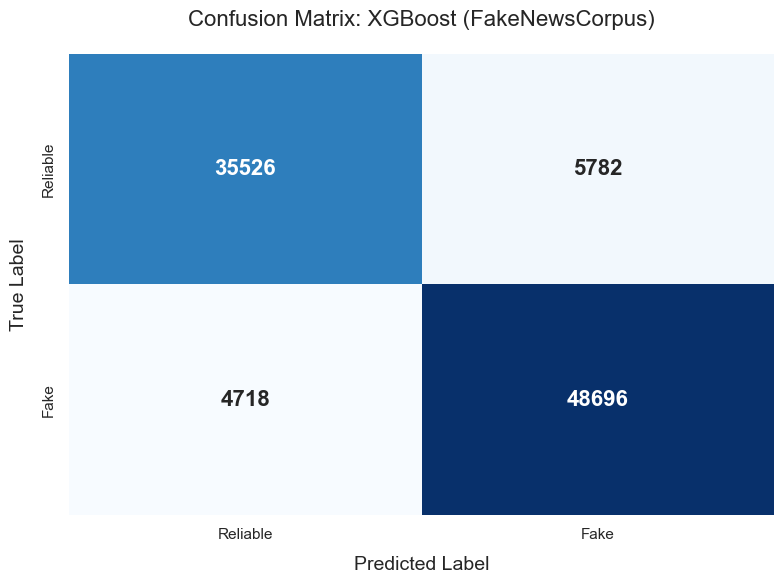

In [18]:
labels = ['Reliable', 'Fake']

plt.figure(figsize=(8, 6))
sns.set_theme(style='white')
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    cbar=False,
    annot_kws={'size': 16, 'weight': 'bold'},
)
plt.xlabel('Predicted Label', fontsize=14, labelpad=10)
plt.ylabel('True Label', fontsize=14, labelpad=10)
plt.title('Confusion Matrix: XGBoost (FakeNewsCorpus)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

## SHAP Exploration

Inspect one randomly selected test row using SHAP values for the text-only model.

Randomly selected row index: 8454
title                              Stifling Dissent in China
content    To the Editor:\n\nRe “China Writer Fights Pena...
type                                                       0
Name: 8454, dtype: object


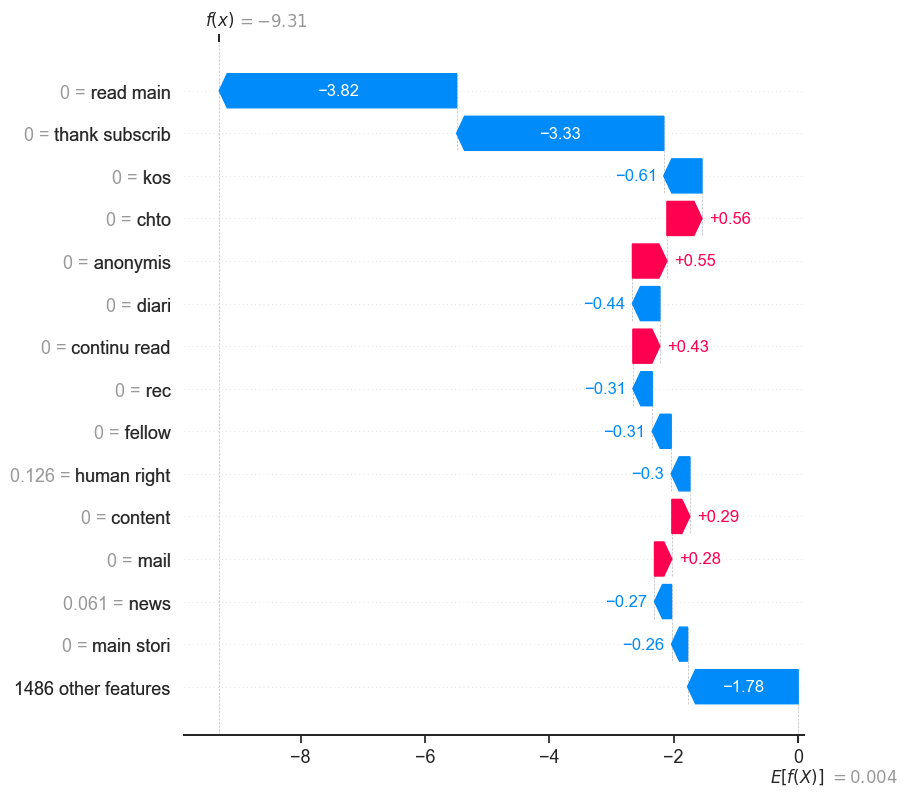

In [19]:
tfidf_feature_names = tfidf.get_feature_names_out().tolist()
xgb_model.get_booster().feature_names = tfidf_feature_names

rng = np.random.default_rng(42)
random_idx = int(rng.integers(0, X_test_final.shape[0]))
random_row = X_test_final[random_idx]

print(f'Randomly selected row index: {random_idx}')
print(test_df.iloc[random_idx][['title', 'content', 'type']])

explainer = shap.TreeExplainer(xgb_model)
random_row_dense = random_row.toarray()
shap_values = explainer.shap_values(random_row_dense)
base_value = explainer.expected_value

if isinstance(base_value, np.ndarray):
    base_value = base_value.item()

shap_explanation = shap.Explanation(
    values=shap_values[0],
    base_values=base_value,
    data=random_row_dense[0],
    feature_names=tfidf_feature_names,
)

shap.plots.waterfall(shap_explanation, max_display=15)